In [6]:
import pandas as pd
housing=pd.read_csv('housing.csv')
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [1]:
import pandas as pd
housing=pd.read_csv('housing.csv')
housing.info()
print(housing["ocean_proximity"].value_counts())
housing.describe()




<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


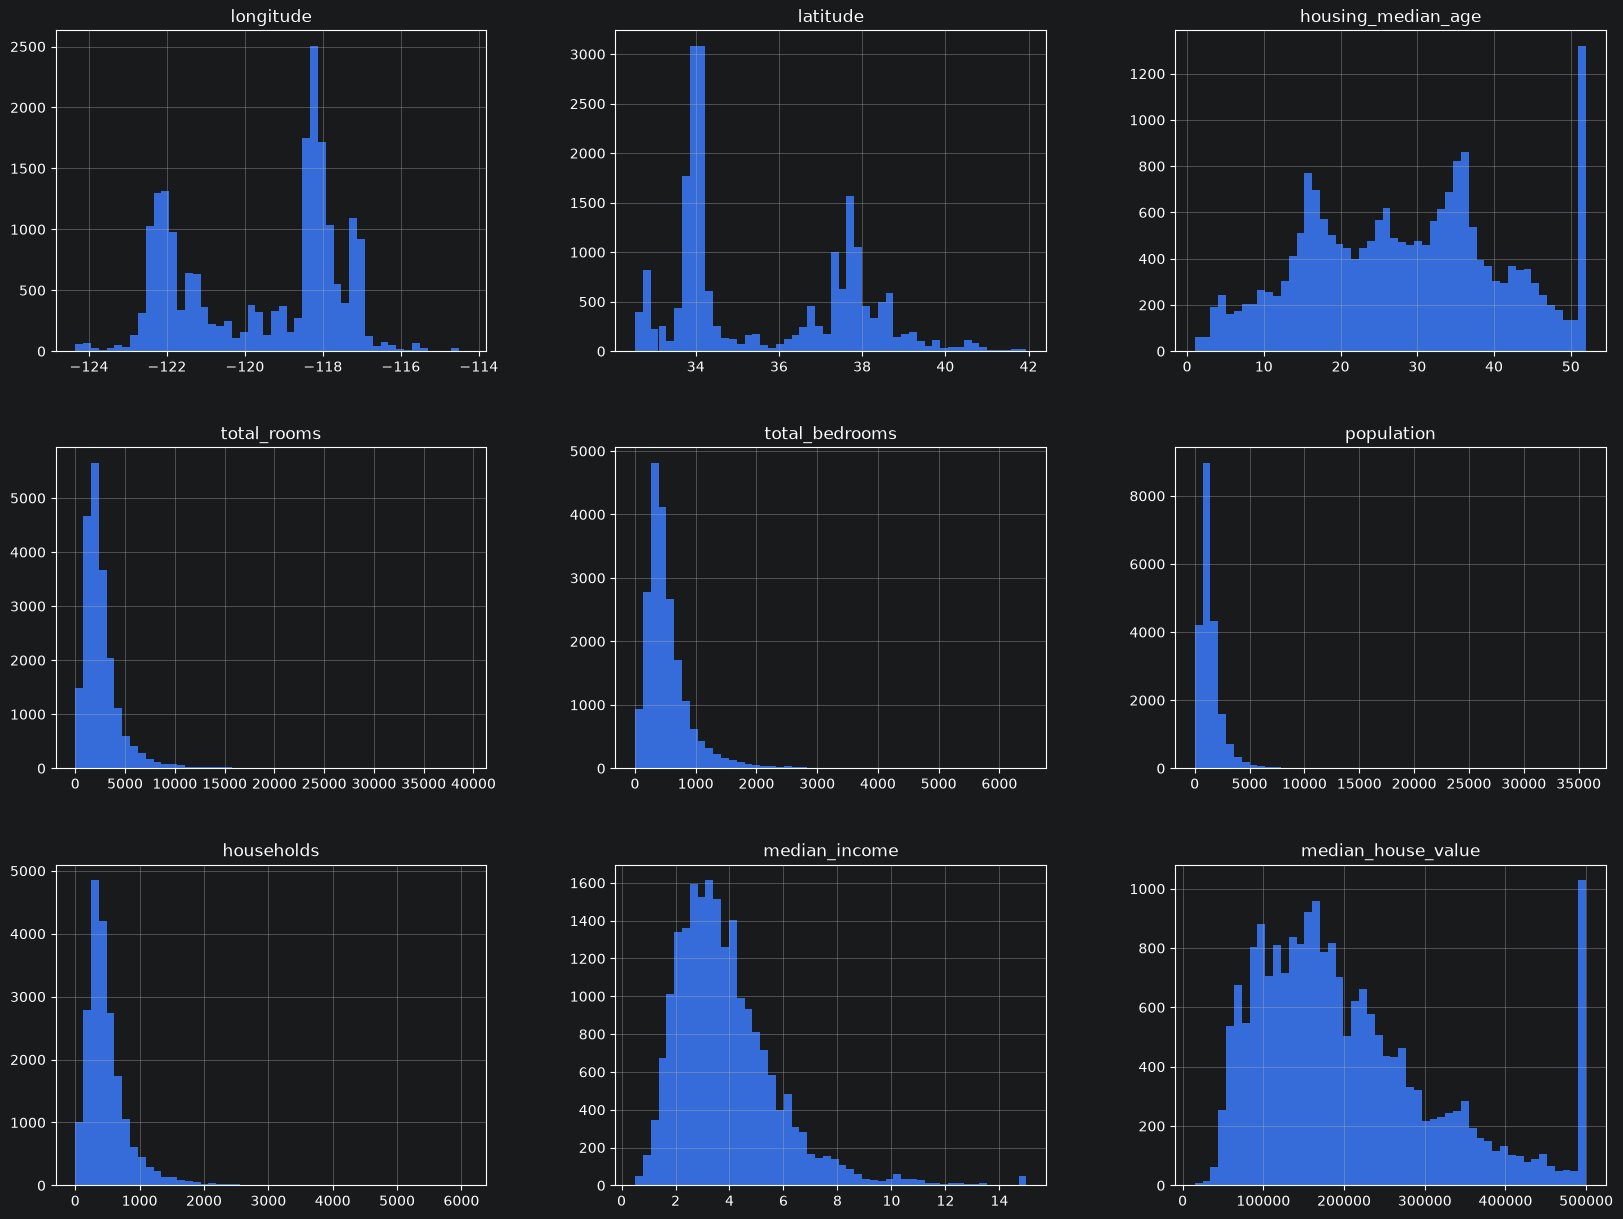

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
housing=pd.read_csv('housing.csv')
housing.hist(bins=50,figsize=(20,15))
plt.show()

In [6]:
import numpy as np
import pandas as pd
housing=pd.read_csv("housing.csv")
# creating the split data fun for train and test
def split_train_test(data,test_ratio):
    shuffled_indices=np.random.permutation(len(data))
    test_set_size=int(len(data)*test_ratio)
    test_indices=shuffled_indices[:test_set_size]
    train_indices=shuffled_indices[test_set_size:]
    return data.iloc[train_indices],data.iloc[test_indices]
train_set,test_set=split_train_test(housing,0.2)
print(len(train_set),"train +",len(test_set),"test")
# creating fun to make test and train set fix even with new data
import hashlib
def test_set_check(identifier,test_ratio,hash):
    return hash(np.int64(identifier).digest()[-1]<256*test_ratio)
def split_train_test_by_id(data,test_ratio,id_column,hash=hashlib.md5):
    ids=data[id_column]
    in_test_set=ids.apply(lambda id_:test_set_check(id_,test_ratio,hash))
    return data.loc[~in_test_set],data.loc[in_test_set]
# housing_with_id["id"]=housing["longitude"]*1000+housing["latitude"]
# train_set,test_set=split_train_test_by_id(housing_with_id,0.2,"id")


16512 train + 4128 test
2cf24dba5fb0a30e26e83b2ac5b9e29e1b161e5c1fa7425e73043362938b9824


In [5]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
housing=pd.read_csv("housing.csv")
train_set,test_set=train_test_split(housing,test_size=0.2,random_state=42)


income_cate
3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: count, dtype: float64


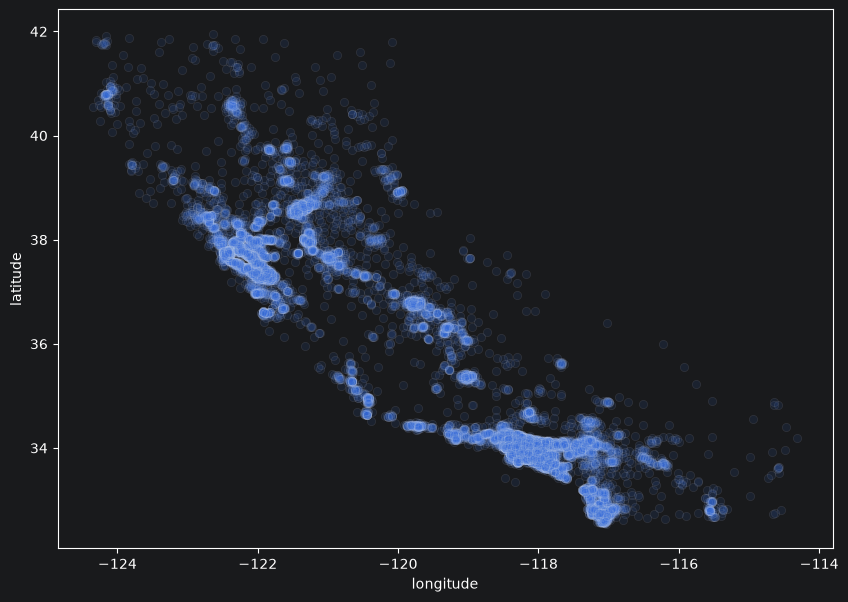

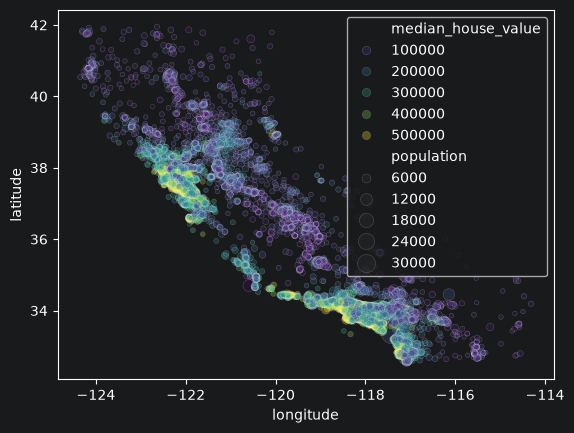

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt
# sns.barplot(data=housing, x="income_cate", y="population")
# plt.title("Average House Value by Income Category")
# plt.show()
housing=pd.read_csv("housing.csv")
housing["income_cate"]=np.ceil(housing["median_income"]/1.5)
housing["income_cate"] = housing["income_cate"].where(housing["income_cate"] < 5, 5.0)
split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index, test_index in split.split(housing,housing["income_cate"]):
    strat_train_set=housing.loc[train_index]
    strat_test_set=housing.loc[test_index]

print(housing["income_cate"].value_counts()/len(housing))
for set_ in (strat_train_set,strat_test_set):
    set_.drop("income_cate",axis=1,inplace=True)





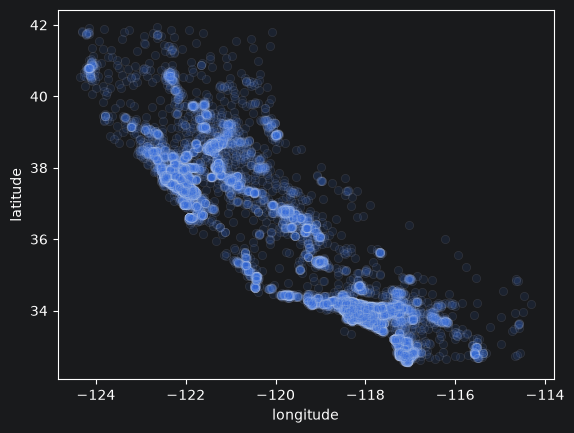

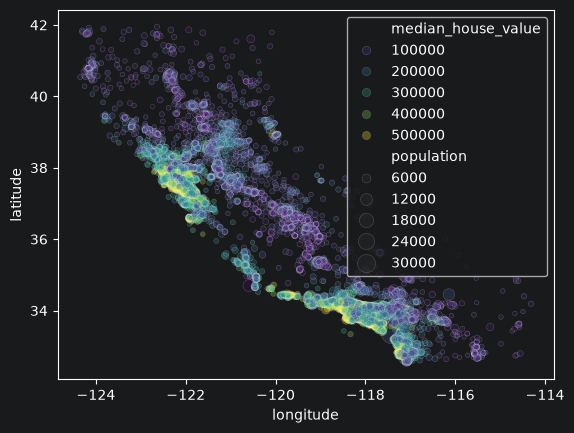

In [16]:
housing =strat_train_set.copy()
sns.scatterplot(data=housing,x="longitude",y="latitude",alpha=0.1)
plt.show()


sns.scatterplot(data=housing, x="longitude", y="latitude", alpha=0.3, size="population",sizes=(10,200),
                 hue="median_house_value", palette="viridis")
plt.legend()


In [20]:
corr_matrix=housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)


median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64